# CLV Prediction Model — XGBoost Training & Evaluation

This notebook trains an **XGBoost regression model** to predict Customer Lifetime Value (CLV) using RFM (Recency, Frequency, Monetary) features and customer cluster assignments.

**Steps covered:**
1. Import required libraries
2. Load the processed RFM dataset
3. Train the XGBoost model
4. Evaluate performance (RMSE, R²)
5. Generate predictions for all customers
6. Visualize results (Predicted vs Actual, Residuals, Feature Importance)

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import sklearn
import xgboost as xgb
import lightgbm as lgb
import plotly
import dash

print("All libraries imported successfully!")
print(f"XGBoost version: {xgb.__version__}")
print(f"LightGBM version: {lgb.__version__}")

All libraries imported successfully!
XGBoost version: 3.3.0
LightGBM version: 4.6.0


## 2. Load Data, Train Model, Evaluate & Export Predictions

This step loads the RFM dataset, trains the XGBoost model on log-transformed monetary value (to handle skewed spending data), evaluates performance, and saves predictions for every customer.

✅ Model trained successfully
RMSE: 14,525.53
R²:   0.4257
📄 Predictions saved to: Notebooks/Outputs/predicted_customer_value.csv


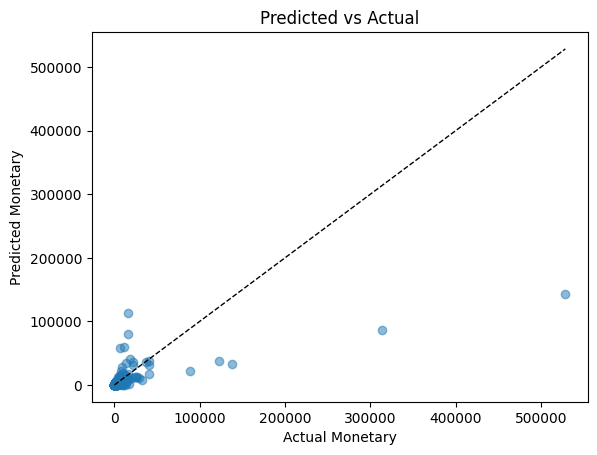

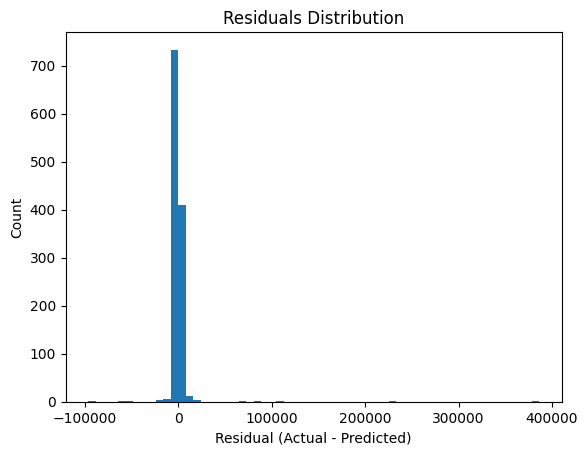

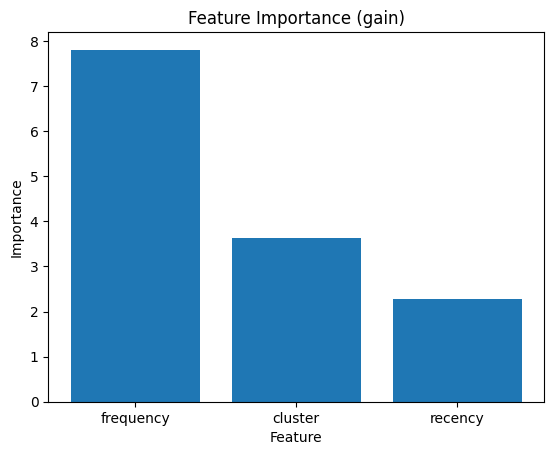

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
import matplotlib.pyplot as plt

# ---- Paths (matches your folder layout) ----
BASE = Path(r"C:\Users\nirma\Desktop\CLV_project\Notebooks\Outputs")
FILE_RFM      = BASE / "rfm_with_clusters_and_segments.csv"
FILE_PRED_OUT = BASE / "predicted_customer_value.csv"

# ---- Load & prep data ----
df = pd.read_csv(FILE_RFM)
df = df.dropna(subset=["monetary", "recency", "frequency"])   # keep complete rows
df["cluster"]  = pd.to_numeric(df.get("cluster"), errors="coerce").fillna(0).astype(int)
df["customer_id"] = df["customer_id"].astype(str)

X = df[["recency", "frequency", "cluster"]].copy()
y = df["monetary"].astype(float)

# log1p target to help the regressor with long-tail
y_log = np.log1p(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

# ---- Model ----
xgb = XGBRegressor(
    n_estimators=400,
    learning_rate=0.07,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    n_jobs=-1,
)
xgb.fit(X_train, y_train)

# ---- Evaluate in monetary space (FIX: rmse = sqrt(mse)) ----
y_pred_log   = xgb.predict(X_test)
y_test_money = np.expm1(y_test)
y_pred_money = np.expm1(y_pred_log)

mse  = mean_squared_error(y_test_money, y_pred_money)
rmse = np.sqrt(mse)
r2   = r2_score(y_test_money, y_pred_money)

print("✅ Model trained successfully")
print(f"RMSE: {rmse:,.2f}")
print(f"R²:   {r2:,.4f}")

# ---- Predict for ALL customers & export ----
df_out = df[["customer_id"]].copy()
df_out["predicted_value"] = np.expm1(xgb.predict(X))
df_out.to_csv(FILE_PRED_OUT, index=False, encoding="utf-8")
print(f"📄 Predictions saved to: {FILE_PRED_OUT}")

# ---- Sanity charts (matplotlib only) ----
# 1) Predicted vs Actual scatter (test set)
plt.figure()
plt.scatter(y_test_money, y_pred_money, alpha=0.5)
plt.plot([0, max(y_test_money.max(), y_pred_money.max())],
         [0, max(y_test_money.max(), y_pred_money.max())],
         linestyle="--", linewidth=1, color="black")
plt.xlabel("Actual Monetary")
plt.ylabel("Predicted Monetary")
plt.title("Predicted vs Actual")
plt.show()

# 2) Residuals histogram
resid = y_test_money - y_pred_money
plt.figure()
plt.hist(resid, bins=60)
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Count")
plt.title("Residuals Distribution")
plt.show()

# 3) Feature importance (gain)
imp = xgb.get_booster().get_score(importance_type="gain")
imp = sorted(imp.items(), key=lambda kv: kv[1], reverse=True)

plt.figure()
plt.bar([k for k, _ in imp], [v for _, v in imp])
plt.title("Feature Importance (gain)")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.show()